# Channel theory sanity check: discrete posterior over training samples

Define the **discrete** posterior over training sample indices:

\[
P(i) = \frac{\exp(-\mathrm{SNR}\, (x_t - s_i)^2)}{Z}, \qquad Z = \sum_j \exp(-\mathrm{SNR}\, (x_t - s_j)^2)
\]

where \(s_i\) are the training samples (e.g. iid \(\mathcal{N}(0, \sigma^2)\)).

**Entropy** of this distribution (nats): \(S = -\sum_i P(i)\,\ln P(i)\).

**Theory:** For the Gaussian channel with signal variance \(\sigma^2\) and \(I(x_t; x_0) = \frac{1}{2}\ln(1 + \mathrm{SNR}\,\sigma^2)\), the posterior entropy over the \(|D|\) training samples should satisfy

\[
S \approx \ln|D| - I(x_t; x_0) = \ln|D| - \frac{1}{2}\ln(1 + \mathrm{SNR}\,\sigma^2).
\]

We compute \(S\) numerically from \(P(i)\) and compare to \(\ln|D| - \frac{1}{2}\ln(1 + \mathrm{SNR}\,\sigma^2)\). The match is only approximate; it is **better at low SNR** and for **larger \(|D|\)**.

In [2]:
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

os.chdir("../")
ROOT = Path(os.path.abspath("")).resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

## Discrete Gibbs posterior and entropy

- **Training samples** \(s_i\): draw \(|D|\) samples from \(\mathcal{N}(0, \sigma^2)\).
- **Observation** \(x_t\): we use \(x_t = s_0 + n\) with \(n \sim \mathcal{N}(0, \sigma^2/\mathrm{SNR})\) so the channel is \(x_t = x_0 + \text{noise}\) with effective SNR.
- **Posterior** \(P(i) = \exp(-\mathrm{SNR}\, (x_t - s_i)^2) / Z\).
- **Entropy** \(S = -\sum_i P(i)\,\ln P(i)\) (nats).
- **Theoretical entropy** \(S_{\mathrm{theory}} = \ln|D| - \frac{1}{2}\ln(1 + \mathrm{SNR}\,\sigma^2)\). The approximation is better at **low SNR** and for **larger \(|D|\)**; at high SNR or small \(|D|\) the numerical \(S\) can sit below \(S_{\mathrm{theory}}\).

In [3]:
def discrete_posterior_entropy_nats(x_t: float, s: np.ndarray, alpha_t: float) -> float:
    """
    P(i) = exp(-SNR * (x_t - s_i)^2) / Z; return S = -sum_i P(i) ln P(i) in nats.
    s: 1d array of training samples.
    """
    logits = -((x_t - np.sqrt(alpha_t)*s) ** 2)/(2*(1 - alpha_t))
    logits = logits - logits.max()  # numerical stability
    p = np.exp(logits)
    z = p.sum()
    if z <= 0:
        return np.nan
    p = p / z
    p = p[p > 0]
    return -np.sum(p * np.log(p))


def theory_entropy_nats(D_size: int, snr: float, sigma_sq: float) -> float:
    """S_theory = ln|D| - (1/2) ln(1 + SNR * sigma^2) (nats)."""
    I = 0.5 * np.log(1.0 + snr * sigma_sq)
    return np.maximum(np.log(D_size) - I, 0.0)

In [4]:
np.random.seed(42)

sigma_sq = 1.0
D_size = 10000   # larger |D| gives better match to S_theory (especially at low SNR)
snr_grid = np.logspace(-5, 15, 32)

# Training samples s_i ~ N(0, sigma^2)
s_train = np.random.randn(D_size) * np.sqrt(sigma_sq)

# For each SNR: generate x_t = s_0 + n, n ~ N(0, sigma^2/SNR), then compute P(i) and S
# Average over multiple x_t for stability
n_trials = 100
entropy_numerical = np.zeros(len(snr_grid))
entropy_theory = np.zeros(len(snr_grid))

for k, snr in enumerate(snr_grid):
    alpha_t = snr/(1+snr)
    beta_t = 1/(1+snr)
    S_list = []
    for _ in range(n_trials):
        s = np.sqrt(sigma_sq)*np.random.randn()
        n = np.random.randn()
        x_t = np.sqrt(alpha_t)*s + np.sqrt(beta_t)*n
        S_list.append(discrete_posterior_entropy_nats(x_t, s_train, alpha_t))
    entropy_numerical[k] = np.mean(S_list)
    entropy_theory[k] = theory_entropy_nats(D_size, snr, sigma_sq)

## Plot: entropy vs SNR

Compare numerical entropy \(S = -\sum_i P(i)\ln P(i)\) (from the discrete posterior over training indices) to \(S_{\mathrm{theory}} = \ln|D| - \frac{1}{2}\ln(1 + \mathrm{SNR}\,\sigma^2)\).

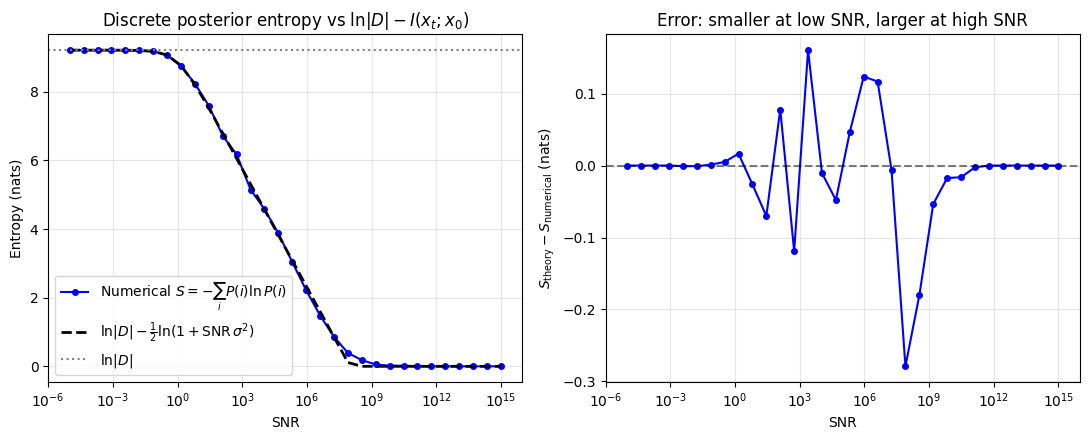

|D| = 10000, sigma^2 = 1.0, n_trials = 100
Max |S_theory - S_numerical|: 0.2790
Mean error at low SNR (first quartile):  0.0010
Mean error at high SNR (last quartile): 0.0023


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: entropy vs SNR
ax = axes[0]
ax.semilogx(snr_grid, entropy_numerical, "b-o", markersize=4, label="Numerical $S = -\\sum_i P(i)\\ln P(i)$")
ax.semilogx(snr_grid, entropy_theory, "k--", linewidth=2, label=r"$\ln|D| - \frac{1}{2}\ln(1 + \mathrm{SNR}\,\sigma^2)$")
ax.axhline(np.log(D_size), color="gray", linestyle=":", label=r"$\ln|D|$")
ax.set_xlabel("SNR")
ax.set_ylabel("Entropy (nats)")
ax.set_title("Discrete posterior entropy vs $\\ln|D| - I(x_t; x_0)$")
ax.legend()
ax.grid(True, alpha=0.3)

# Right: error vs SNR (match is better at low SNR)
axes[1].semilogx(snr_grid, entropy_theory - entropy_numerical, "b-o", markersize=4)
axes[1].axhline(0, color="k", linestyle="--", alpha=0.5)
axes[1].set_xlabel("SNR")
axes[1].set_ylabel(r"$S_{\mathrm{theory}} - S_{\mathrm{numerical}}$ (nats)")
axes[1].set_title("Error: smaller at low SNR, larger at high SNR")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

error = entropy_theory - entropy_numerical
max_diff = np.max(np.abs(error))
print(f"|D| = {D_size}, sigma^2 = {sigma_sq}, n_trials = {n_trials}")
print(f"Max |S_theory - S_numerical|: {max_diff:.4f}")
# Error should be smaller at low SNR
idx_low = len(snr_grid) // 4
idx_high = -len(snr_grid) // 4
print(f"Mean error at low SNR (first quartile):  {np.mean(np.abs(error[:idx_low])):.4f}")
print(f"Mean error at high SNR (last quartile): {np.mean(np.abs(error[idx_high:])):.4f}")

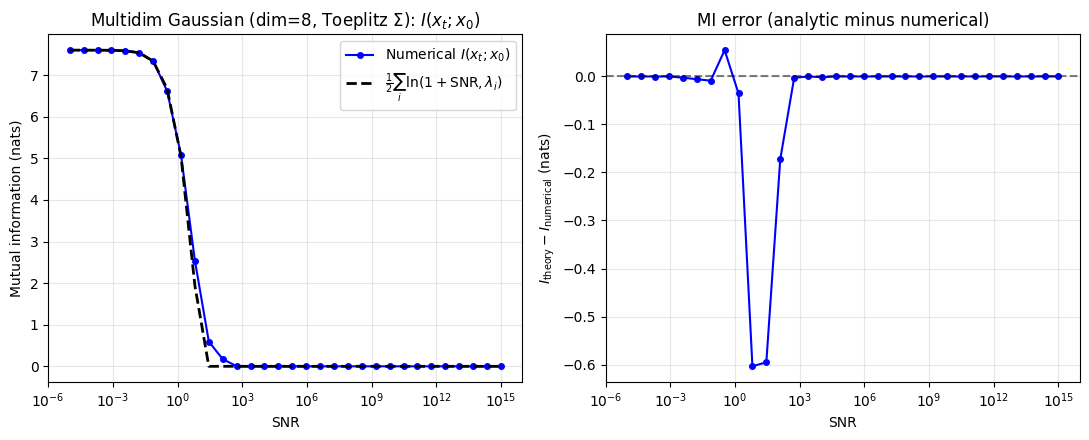

In [15]:
# Multidimensional Gaussian channel with Toeplitz covariance: sanity check
# Compare discrete posterior entropy (via mutual information) to analytic
# I(x_t; x_0) = 1/2 * sum_i log(1 + SNR * lambda_i), where lambda_i are eigenvalues of Sigma.

# Dimension and Toeplitz covariance parameters
dim = 8
rho = 0.8  # correlation between neighboring dimensions

idx = np.arange(dim)
toeplitz = rho ** np.abs(idx[None, :] - idx[:, None])
Sigma_s = sigma_sq * toeplitz  # use same sigma_sq as in 1D sanity check

# Eigenvalues of Sigma_s for analytic mutual information
eigvals = np.linalg.eigvalsh(Sigma_s)

D_size_vec = 2000
n_trials_vec = 50

# Precompute training samples s_i ~ N(0, Sigma_s)
L = np.linalg.cholesky(Sigma_s)
z_train = np.random.randn(D_size_vec, dim)
s_train_vec = z_train @ L.T  # [D_size_vec, dim]

entropy_numerical_vec = np.zeros(len(snr_grid))
entropy_theory_vec = np.zeros(len(snr_grid))
mi_theory_vec = np.zeros(len(snr_grid))

for k, snr in enumerate(snr_grid):
    alpha_t = snr / (1.0 + snr)
    beta_t = 1.0 / (1.0 + snr)

    S_list = []
    for _ in range(n_trials_vec):
        # One clean sample s0 ~ N(0, Sigma_s)
        g = np.random.randn(dim)
        s0 = g @ L.T
        # Noise and observation
        n = np.random.randn(dim)
        x_t = np.sqrt(alpha_t) * s0 + np.sqrt(beta_t) * n

        # Discrete posterior over training samples
        diff = x_t[None, :] - np.sqrt(alpha_t) * s_train_vec  # [D_size_vec, dim]
        sq_norm = np.sum(diff * diff, axis=1)
        logits = -sq_norm / (2.0 * beta_t)
        logits = logits - logits.max()  # numerical stability
        p = np.exp(logits)
        Z = p.sum()
        if Z <= 0:
            continue
        p = p / Z
        p = p[p > 0]
        S_list.append(-np.sum(p * np.log(p)))

    entropy_numerical_vec[k] = np.mean(S_list)
    mi_theory_vec[k] = 0.5 * np.sum(np.log(1.0 + snr * eigvals))
    entropy_theory_vec[k] = np.maximum(0.0, np.log(D_size_vec) - mi_theory_vec[k])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: mutual information vs SNR
ax = axes[0]
ax.semilogx(snr_grid, entropy_numerical_vec, "b-o", markersize=4, label="Numerical $I(x_t; x_0)$")
ax.semilogx(snr_grid, entropy_theory_vec, "k--", linewidth=2,
            label=r"$\frac{1}{2}\sum_i \ln(1+\mathrm{SNR},\lambda_i)$")
ax.set_xlabel("SNR")
ax.set_ylabel("Mutual information (nats)")
ax.set_title(f"Multidim Gaussian (dim={dim}, Toeplitz $\\Sigma$): $I(x_t; x_0)$")
ax.legend()
ax.grid(True, alpha=0.3)

# Right: error in mutual information
axes[1].semilogx(snr_grid, entropy_theory_vec - entropy_numerical_vec, "b-o", markersize=4)
axes[1].axhline(0.0, color="k", linestyle="--", alpha=0.5)
axes[1].set_xlabel("SNR")
axes[1].set_ylabel(r"$I_{\mathrm{theory}} - I_{\mathrm{numerical}}$ (nats)")
axes[1].set_title("MI error (analytic minus numerical)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
np.log(n_trials_vec)

3.912023005428146